In [1]:
import pandas as pd 
import requests
import time
import os
import numpy as np
import py3Dmol
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley
import matplotlib.pyplot as plt




In [2]:
path = "/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classI_final.csv"

data = pd.read_csv(path)

print(data.head())

   ID Peptide Sequence Best HLA Allele      Tissue                   Disease  \
0   1        NAIEGGTQL     HLA-C*03:04        PBMC  chronic myeloid leukemia   
1   2        SYQGKGFVM             NaN  LYMPH_NODE       lung adenocarcinoma   
2   3        VYVPHIHVW     HLA-A*24:02      KIDNEY      renal cell carcinoma   
3   4        KIYEGQVEV     HLA-A*02:01       LIVER  hepatocellular carcinoma   
4   5        SPRGAGWLF             NaN        PBMC      mantle cell lymphoma   

  MHC Class  Peptide Modifications Uniprot IDs  Affinity % Rank  length  ...  \
0         I                    NaN      O60832              NaN       9  ...   
1         I                    NaN      Q92692              NaN       9  ...   
2         I                    NaN      Q6PL18              NaN       9  ...   
3         I                    NaN      P46777              NaN       9  ...   
4         I                    NaN      O00743              NaN       9  ...   

    aa_pct_T   aa_pct_V   aa_pct_W   a

In [3]:
overall_data = "/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classI_final.csv"
overall_df = pd.read_csv(overall_data)



print(overall_df.head())


   ID Peptide Sequence Best HLA Allele      Tissue                   Disease  \
0   1        NAIEGGTQL     HLA-C*03:04        PBMC  chronic myeloid leukemia   
1   2        SYQGKGFVM             NaN  LYMPH_NODE       lung adenocarcinoma   
2   3        VYVPHIHVW     HLA-A*24:02      KIDNEY      renal cell carcinoma   
3   4        KIYEGQVEV     HLA-A*02:01       LIVER  hepatocellular carcinoma   
4   5        SPRGAGWLF             NaN        PBMC      mantle cell lymphoma   

  MHC Class  Peptide Modifications Uniprot IDs  Affinity % Rank  length  ...  \
0         I                    NaN      O60832              NaN       9  ...   
1         I                    NaN      Q92692              NaN       9  ...   
2         I                    NaN      Q6PL18              NaN       9  ...   
3         I                    NaN      P46777              NaN       9  ...   
4         I                    NaN      O00743              NaN       9  ...   

    aa_pct_T   aa_pct_V   aa_pct_W   a

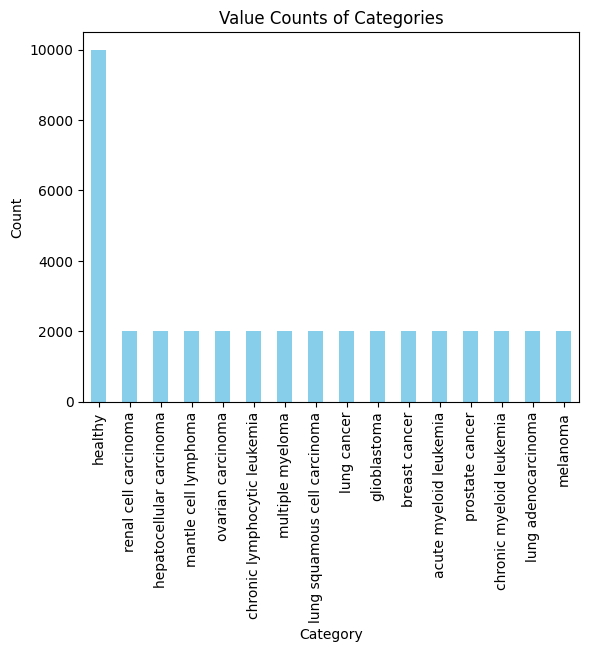

In [4]:
tissue_counts = overall_df['Disease'].value_counts()
tissue_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Value Counts of Categories')
plt.show()


In [5]:
tissues = overall_df['Tissue'].unique()

for tissue in tissues:
    # 2. Filter the dataframe where the Tissue matches AND the Disease is 'healthy'
    healthy_tissue_df = overall_df[(overall_df['Tissue'] == tissue) & (overall_df['Disease'] == 'healthy')]
    
    # 3. Print the count
    print(f"Tissue: {tissue}, Healthy Count: {len(healthy_tissue_df)}, Total Count: {len(overall_df[overall_df['Tissue'] == tissue])}, Healthy Percentage: {len(healthy_tissue_df) / len(overall_df[overall_df['Tissue'] == tissue]) * 100:.2f}%")

Tissue: PBMC, Healthy Count: 0, Total Count: 10142, Healthy Percentage: 0.00%
Tissue: LYMPH_NODE, Healthy Count: 0, Total Count: 1458, Healthy Percentage: 0.00%
Tissue: KIDNEY, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: LIVER, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: OVARY, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: OTHER, Healthy Count: 10000, Total Count: 10000, Healthy Percentage: 100.00%
Tissue: SKIN, Healthy Count: 0, Total Count: 1082, Healthy Percentage: 0.00%
Tissue: LUNG, Healthy Count: 0, Total Count: 5311, Healthy Percentage: 0.00%
Tissue: BRAIN, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: MAMMA, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: PROSTATE, Healthy Count: 0, Total Count: 2000, Healthy Percentage: 0.00%
Tissue: BONE_MARROW, Healthy Count: 0, Total Count: 3, Healthy Percentage: 0.00%


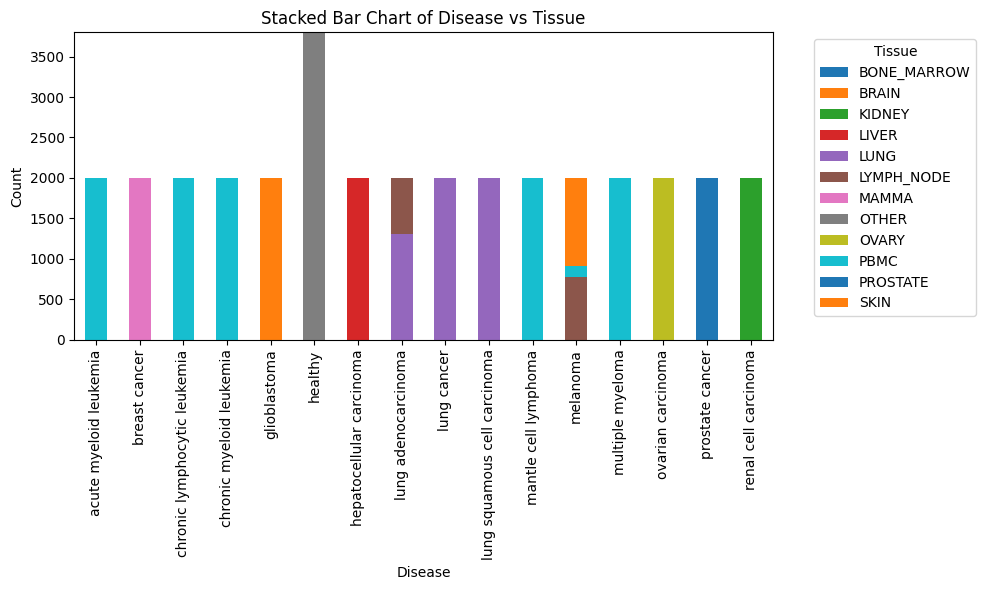

In [6]:
pd.crosstab(overall_df['Disease'], overall_df['Tissue']).sort_index(axis=0, ascending=True).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Disease')
plt.ylabel('Count')
plt.ylim(0,3800)
plt.title('Stacked Bar Chart of Disease vs Tissue')
plt.legend(title='Tissue', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




In [ ]:
import os
import requests
import py3Dmol
import numpy as np
import urllib3
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley

# 1. Suppress the annoying warnings from using verify=False
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# (Assuming 'data' is your pandas DataFrame loaded earlier)
# peptide_sequence = data.iloc[4]['Peptide Sequence'] 
peptide_sequence = "SPRGAGWLF" # Hardcoded for testing
previous_peptide = None

output_dir = "Data/peptide_structures" 
os.makedirs(output_dir, exist_ok=True) 
pdb_filename = os.path.join(output_dir, f"{peptide_sequence}.pdb") 

# 2. Call API with a robust Session
def fetch_peptide_structure(sequence, filename):  
    url = "https://api.esmatlas.com/foldSequence/v1/pdb/"
    
    # Adding headers helps prevent load balancers from dropping the connection
    headers = {
        'Content-Type': 'text/plain',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'
    }
    
    # Set up a session with automatic retries for standard connection drops
    session = requests.Session()
    retries = Retry(total=3, backoff_factor=1, status_forcelist=[500, 502, 503, 504])
    session.mount('https://', HTTPAdapter(max_retries=retries))

    try: 
        response = session.post(url, data=sequence, headers=headers, verify=False, timeout=15)
        
        if response.status_code == 200:
            return response.text
        else:
            print(f"Server returned status code: {response.status_code}")
            return None
        
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return None
    
if previous_peptide:
    print(previous_peptide)
    
print(f"Fetching structure for peptide: {peptide_sequence}...")
previous_peptide = peptide_sequence
pdb_data = fetch_peptide_structure(peptide_sequence, pdb_filename)

if pdb_data:
    # 3. Save Data
    with open(pdb_filename, "w") as f:
        f.write(pdb_data)
    print(f"Success! Saved to {pdb_filename}")

    # 4. VISUALIZE: Show 3D structure in VS Code / Jupyter
    view = py3Dmol.view(width=400, height=300)
    view.addModel(pdb_data, "pdb")
    view.setStyle({'model': -1}, {"cartoon": {'color': 'spectrum'}}) 
    view.zoomTo()
    view.show()

    # 5. ANALYZE: Calculate "Qualities" 
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("peptide", pdb_filename)

    # A. Radius of Gyration 
    atoms = list(structure.get_atoms())
    coords = np.array([atom.get_coord() for atom in atoms])
    center_of_mass = coords.mean(axis=0)
    rg = np.sqrt(np.sum((coords - center_of_mass)**2) / len(atoms))
    
    # B. SASA 
    sr = ShrakeRupley()
    sr.compute(structure, level="S") 
    total_sasa = structure.sasa
    
    # C. Confidence (pLDDT)
    b_factors = [atom.bfactor for atom in atoms]
    avg_plddt = sum(b_factors) / len(b_factors)

    print("-" * 30)
    print(f"FEATURE REPORT FOR {peptide_sequence}")
    print("-" * 30)
    print(f"1. Confidence (pLDDT): {avg_plddt:.2f} (0-100, >70 is good)")
    print(f"2. Radius of Gyration: {rg:.2f} Å (Lower = More Compact)")
    print(f"3. Total Surface Area: {total_sasa:.2f} Å²")
    print("-" * 30)

else:
    print("Failed to generate structure.")

Fetching structure for peptide: SPRGAGWLF...
Request failed: HTTPSConnectionPool(host='api.esmatlas.com', port=443): Max retries exceeded with url: /foldSequence/v1/pdb/ (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)')))
Failed to generate structure.
